# Preset: `env7`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Hand-designed layout

In [2]:
layout_str = """
 _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _
|_|      _ _  |_|_|_| |_|_|     |_|_|   |
|    _  |_|_|  _|_|_|   |_|  _    |_|   |
|  _|_| |_|_| |_|_|  _      |_|_   _    |
| |_|_|    _    |_| |_|_ _  |_|_| |_|_ _|
|_ _     _|_|_   _  |_|_|_|  _   _    |_|
|_|_|   |_|_|_|_|_|   |_|  _|_| |_|_    |
|_|    _   _    |_|    _ _|    _    |_  |
|_|   |_|_|_|  _ _    |_|_|   |_|  _|_| |
|_|_    |_|   |_|_|_ _     _  |_| |_|  _|
|_|_|_     _  |_|   |_|   |_| |_|  _  |_|
|_|_|_|  _|_|      _      |_|_    |_|   |
|_|     |_|_ _    |_|  _    |_|  _|_|   |
|_|_    |_|_|_|   |_| |_|       |_|  _  |
|_|_|     |_|_         _|  _ _ _ _ _|_| |
|_|_|  _  |_|_|  _ _ _|   |_|_|    _    |
|_|  _|_|       |_|_|_ _     _ _ _|_|   |
|_| |_|_ _     _   _  |_|   |_|_|_|    _|
|  _  |_|_|_ _|_| |_|    _ _ _  |_|   |_|
| |_|  _ _  |_|    _ _  |_|_|_|      _|_|
|_ _ _|_|_|_ _ _ _|_|_|_ _|_|_ _ _ _|_|_|
"""

In [3]:
n_segments = 20
env_width = 36.
env_halfwidth = env_width / 2.

delims = np.linspace(-env_halfwidth, env_halfwidth, n_segments+1)
delims

array([-18. , -16.2, -14.4, -12.6, -10.8,  -9. ,  -7.2,  -5.4,  -3.6,
        -1.8,   0. ,   1.8,   3.6,   5.4,   7.2,   9. ,  10.8,  12.6,
        14.4,  16.2,  18. ])

## Extract wall data

### Edges

In [4]:
edges = []
hor_mask = np.zeros((len(delims), len(delims)-1), dtype=np.bool_)
ver_mask = np.zeros((len(delims)-1, len(delims)), dtype=np.bool_)

ver_idx = 0

for line in layout_str.split('\n'):
    if line == '':
        continue

    hor_idx = 0
    char_ctr = 0

    for char in line:
        if char == '|':
            ver_mask[ver_idx-1, hor_idx] = True
            edge = ((delims[hor_idx], delims[ver_idx-1]), (delims[hor_idx], delims[ver_idx]))
            edges.append(edge)

        elif char == '_':
            hor_mask[ver_idx, hor_idx] = True
            edge = ((delims[hor_idx], delims[ver_idx]), (delims[hor_idx+1], delims[ver_idx]))
            edges.append(edge)

        hor_idx += char_ctr % 2
        char_ctr += 1

    ver_idx += 1

edges = np.array(edges)
edges.shape, edges

((472, 2, 2),
 array([[[-18. , -18. ],
         [-16.2, -18. ]],
 
        [[-16.2, -18. ],
         [-14.4, -18. ]],
 
        [[-14.4, -18. ],
         [-12.6, -18. ]],
 
        ...,
 
        [[ 16.2,  16.2],
         [ 16.2,  18. ]],
 
        [[ 16.2,  18. ],
         [ 18. ,  18. ]],
 
        [[ 18. ,  16.2],
         [ 18. ,  18. ]]]))

### Links

In [5]:
edge_pts = np.unique(edges.reshape(-1, 2), axis=0)
len(edge_pts), edge_pts[:10]

(371,
 array([[-18. , -18. ],
        [-18. , -16.2],
        [-18. , -14.4],
        [-18. , -12.6],
        [-18. , -10.8],
        [-18. ,  -9. ],
        [-18. ,  -7.2],
        [-18. ,  -5.4],
        [-18. ,  -3.6],
        [-18. ,  -1.8]]))

### Masks

In [6]:
hor_mask.astype(np.int64), '\n', ver_mask.astype(np.int64)

(array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0],
        [0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0],
        [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1],
        [1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1],
        [1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0],
        [1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0],
        [1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0],
        [1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
        [1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
        [1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0],
        [1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0],
        [1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0],
        [1, 1, 0, 0,

## Connection graph

In [7]:
hor_con_mask = ~hor_mask
ver_con_mask = ~ver_mask
delim_centres = (delims[1:] + delims[:-1]) / 2.

con_edges = []

# Iterate over grid square index coordinates
for i, i_prev, i_post in zip(range(n_segments), range(-1, n_segments-1), range(1, n_segments+1)):
    for j, j_post in zip(range(n_segments), range(1, n_segments+1)):
        og_node = (i, j)
        hor_node = (i, j_post)
        ver_node = (i_post, j)
        ldiag_node = (i_post, j_post)
        udiag_node = (i_prev, j_post)

        # Check for connections
        hor_con = (j_post < n_segments) and ver_con_mask[hor_node]
        ver_con = (i_post < n_segments) and hor_con_mask[ver_node]

        ldiag_con = (
            hor_con and
            ver_con and
            hor_con_mask[ldiag_node] and
            ver_con_mask[ldiag_node])

        udiag_con = (
            hor_con and
            hor_con_mask[og_node] and
            ver_con_mask[udiag_node] and
            hor_con_mask[hor_node])

        # Add connections to the graph
        # NOTE: This is yx format...
        if hor_con:
            edge = ((delim_centres[i], delim_centres[j]), (delim_centres[i], delim_centres[j_post]))
            con_edges.append(edge)

        if ver_con:
            edge = ((delim_centres[i], delim_centres[j]), (delim_centres[i_post], delim_centres[j]))
            con_edges.append(edge)

        if ldiag_con:
            edge = ((delim_centres[i], delim_centres[j]), (delim_centres[i_post], delim_centres[j_post]))
            con_edges.append(edge)

        if udiag_con:
            edge = ((delim_centres[i], delim_centres[j]), (delim_centres[i_prev], delim_centres[j_post]))
            con_edges.append(edge)

con_edges = np.array(con_edges)
len(con_edges), con_edges

(508,
 array([[[-17.1, -15.3],
         [-17.1, -13.5]],
 
        [[-17.1, -15.3],
         [-15.3, -15.3]],
 
        [[-17.1, -15.3],
         [-15.3, -13.5]],
 
        ...,
 
        [[ 17.1,   9.9],
         [ 15.3,  11.7]],
 
        [[ 17.1,  11.7],
         [ 17.1,  13.5]],
 
        [[ 17.1,  11.7],
         [ 15.3,  13.5]]]))

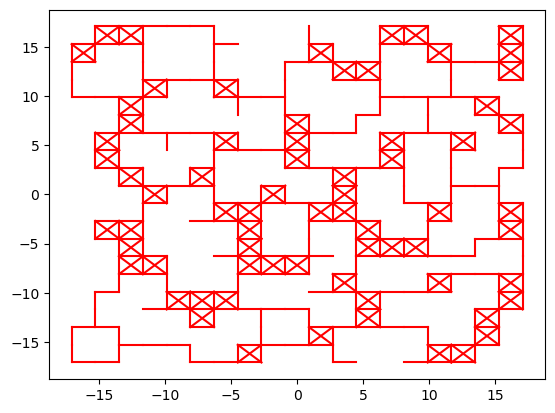

In [8]:
plt.plot(con_edges[..., 1].T, con_edges[..., 0].T*-1, 'r');

### Nodes (free squares)

In [9]:
con_edge_pts = np.unique(con_edges.reshape(-1, 2), axis=0)
len(con_edge_pts), con_edge_pts[:10]

(279,
 array([[-17.1, -15.3],
        [-17.1, -13.5],
        [-17.1, -11.7],
        [-17.1,  -9.9],
        [-17.1,  -8.1],
        [-17.1,  -6.3],
        [-17.1,   0.9],
        [-17.1,   6.3],
        [-17.1,   8.1],
        [-17.1,   9.9]]))

## Hand-set colour indices

In [10]:
_ = """
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
433      0 0  3333333 55555     55555   4
4    0  00000  333333   555  2    555   4
4  0000 00000 33333  5      2222   5    4
4 00000    3    333 5555 5  22222 5555 54
43 3     33333   3  5555555  1   1    554
43333   33333333333   555  1111 1111    4
433    0   0    333    1 11    2    11  4
433   0000000  6 6    11111   222  1111 4
4333    000   666666 6     1  222 111  84
433333     6  666   666   111 222  1  884
4333333  6666      2      1111    111   4
477     6666 6    222  6    111  1111   4
4777    6666666   222 666       111  8  4
47777     6666         66  8 8 8 8 8888 4
47777  7  66666  6 6 66   88888    0    4
477  7777       666666 6     0 0 0000   4
477 7777 7     7   2  666   0000000    84
4  2  777777 7777 222    0 0 0  000   884
4 222  7 7  777    8 8  0000000      8884
|_ _ _7_7_7_ _ _ _84848_ _0_0_ _ _ _84844
 _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _
4_3      _ _  3_3_3_3 5_5_5     5_5_5   4
4    _  0_0_0  _3_3_3   5_5  _    5_5   4
4  _0_0 0_0_0 3_3_3  _      2_2_   _    4
4 0_0_0    _    3_3 5_5_ _  2_2_2 5_5_ _4
4_ _     _3_3_   _  5_5_5_5  _   _    5_4
4_3_3   3_3_3_3_3_3   5_5  _1_1 1_1_    4
4_3    _   _    3_3    _ _1    _    1_  4
4_3   0_0_0_0  _ _    1_1_1   2_2  _1_1 4
4_3_    0_0   6_6_6_ _     _  2_2 1_1  _4
4_3_3_     _  6_6   6_6   1_1 2_2  _  8_4
4_3_3_3  _6_6      _      1_1_    1_1   4
4_7     6_6_ _    2_2  _    1_1  _1_1   4
4_7_    6_6_6_6   2_2 6_6       1_1  _  4
4_7_7     6_6_         _6  _ _ _ _ _8_8 4
4_7_7  _  6_6_6  _ _ _6   8_8_8    _    4
4_7  _7_7       6_6_6_ _     _ _ _0_0   4
4_7 7_7 7      _   _  6_6   0_0_0_0    _4
4  _  7_7_7_ _7_7 2_2    _ _ _  0_0   8_4
4 2_2  _ _  7_7    _ _  0_0_0_0      _8_4
4_ _ _7_7_7_ _ _ _8_8_8_ _0_0_ _ _ _8_8_4

 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
|3|      0 0  |3|3|3| |5|5|     |5|5|   |
|    0  |0|0|  3|3|3|   |5|  2    |5|   |
|  0|0| |0|0| |3|3|  5      |2|2   5    |
| |0|0|    3    |3| |5|5 5  |2|2| |5|5 5|
|3 3     3|3|3   3  |5|5|5|  1   1    |5|
|3|3|   |3|3|3|3|3|   |5|  1|1| |1|1    |
|3|    0   0    |3|    1 1|    2    |1  |
|3|   |0|0|0|  6 6    |1|1|   |2|  1|1| |
|3|3    |0|   |6|6|6 6     1  |2| |1|  8|
|3|3|3     6  |6|   |6|   |1| |2|  1  |8|
|3|3|3|  6|6|      2      |1|1    |1|   |
|7|     |6|6 6    |2|  6    |1|  1|1|   |
|7|7    |6|6|6|   |2| |6|       |1|  8  |
|7|7|     |6|6         6|  8 8 8 8 8|8| |
|7|7|  7  |6|6|  6 6 6|   |8|8|    0    |
|7|  7|7|       |6|6|6 6     0 0 0|0|   |
|7| |7|7 7     7   2  |6|   |0|0|0|    8|
|  2  |7|7|7 7|7| |2|    0 0 0  |0|   |8|
| |2|  7 7  |7|    8 8  |0|0|0|      8|8|
|4 4 4|4|4|4 4 4 4|4|4|4 4|4|4 4 4 4|4|4|
"""

hor_idx_str = """
 _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _
4_3 3 3 0_0_0 3_3_3_3 5_5_5 5 5 5_5_5 5 4
4 0 0_0 0_0_0 3_3_3_3 5 5_5 5_5 5 5_5 5 4
4 0_0_0 0_0_0 3_3_3 5_5 5 5 2_2_2 5_5 5 4
4 0_0_0 0 3_3 3 3_3 5_5_5_5 2_2_2 5_5_5_4
4_3_3 3 3_3_3_3 3_3 5_5_5_5 5_5 5_5 5 5_4
4_3_3 3 3_3_3_3_3_3 5 5_5 5_1_1 1_1_1 1 4
4_3 3 3_3 3_3 3 3_3 1 1_1_1 1 1_1 1 1_1 4
4_3 3 0_0_0_0 3_3_3 1 1_1_1 1 2_2 1_1_1 4
4_3_3 0 0_0 0 6_6_6_6_6 6 1_1 2_2 1_1 1_4
4_3_3_3 6 6_6 6_6 6 6_6 6 1_1 2_2 1_1 8_4
4_3_3_3 6_6_6 6 6 6_6 6 6 1_1_1 1 1_1 8 4
4_7 7 7 6_6_6_6 6 2_2 6_6 1 1_1 1_1_1 8 4
4_7_7 7 6_6_6_6 6 2_2 6_6 1 1 1 1_1 8_8 4
4_7_7 7 6 6_6_6 6 6 6 6_6 8_8_8_8_8_8_8 4
4_7_7 7_6 6_6_6 6_6_6_6 6 8_8_8 8 8_8 8 4
4_7 7_7_7 6 6 6 6_6_6_6_6 8 0_0_0_0_0 8 4
4_7 7_7 7 6 6 6_6 6_6 6_6 8 0_0_0_0 0 8_4
4 7_7 7_7_7_7_7_7 2_2 8 8_8_0_0 0_0 0 8_4
4 2_2 7_7_7 7_7 8 8_8_8 0_0_0_0 8 8 8_8_4
4_7_7_7_7_7_7_7_8_8_8_8_0_0_0_0_8_8_8_8_4
"""

ver_idx_str = """
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
|3|3 3 3 0 0 3|3|3|3|5|5|5|5 5 5|5|5|5 5|
|3 0 0 0|0|0|3 3|3|3|5 5|5|5 2 2 5|5|5 5|
|3 0|0|0|0|0|3|3|3|3 5 5 5 5|2|2 5 5 5 5|
|3|0|0|0 3 3 3 3|3|3|5|5 5 5|2|2|5|5|5 5|
|3 3 3 3 3|3|3 3 3 3|5|5|5|1 1 1 1 5 5|5|
|3|3|3 3|3|3|3|3|3|3 5|5|5 1|1|1|1|1 1 1|
|3|3 3 0 0 0 3 3|3|3 1 1 1|1 1 2 1 1|1 1|
|3|3 3|0|0|0|6 6 6 6 6|1|1|1 1|2|1 1|1|1|
|3|3 3 0|0|0 6|6|6|6 6 6 1 1 1|2|1|1|1 8|
|3|3|3 3 6 6 6|6|6 6|6|6 1|1|1|2|1 1 1|8|
|3|3|3|3 6|6|6 6 6 2 6 6 1|1|1 1 1|1|1 8|
|7|7 7 7|6|6 6 6 6|2|6 6 1 1|1|1 1|1|1 8|
|7|7 7 7|6|6|6|6 6|2|6|6|1 1 1 1|1|8 8 8|
|7|7|7 7 6|6|6 6 6 6 6 6|8 8 8 8 8 8|8|8|
|7|7|7 7 6|6|6|6 6 6 6|6 8|8|8|8 0 0 8 8|
|7|7 7|7|6 6 6 6|6|6|6 6 8 8 0 0 0|0|8 8|
|7|7|7|7 7 7 7 7 6 2 6|6|8 8|0|0|0|0 8 8|
|7 2 7|7|7|7 7|7|8|2|8 8 0 0 0 0|0|0 8|8|
|7|2|7 7 7 7|7|7 8 8 8 8|0|0|0|8 8 8 8|8|
|4 4 4|4|4|4 4 4 4|4|4|4 4|4|4 4 4 4|4|4|
"""

clr_idx_str = ""

for hor_idx_char, ver_idx_char in zip(hor_idx_str, ver_idx_str):
    clr_idx_str += ver_idx_char if hor_idx_char == '_' or hor_idx_char == ' ' else hor_idx_char

print(clr_idx_str)


 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
43333333000003333333355555555555555555554
43000000000003333333355555555252555555554
43000000000003333333555555552222255555554
43000000033333333333555555552222255555554
43333333333333333333555555515151515555554
43333333333333333333555555511111111111114
43333330303033333333111111111112111111114
43333300000006363636161111111122211111114
43333300000006666666666661111122211111184
43333333666666666666666661111122211111884
43333333666666666662666661111111111111884
47777777666666666622266661111111111111884
47777777666666666622266661111111111888884
47777777666666666666666668888888888888884
47777777666666666666666668888888808088884
47777777766666666666666668880000000008884
47777777776767676662666668880000000008884
47727777777777777822288880800000000008884
47222777777777778888888800000008888888884
44747474747474748484848404040404848484844



### Wall colours

In [11]:
hor_clrs = np.ones((len(delims), len(delims)-1), dtype=np.int64) * -1
ver_clrs = np.ones((len(delims)-1, len(delims)), dtype=np.int64) * -1

ver_idx = 0

for line in clr_idx_str.split('\n'):
    if line == '':
        continue

    hor_idx = 0
    char_ctr = 0

    for char in line:
        if char_ctr % 2:
            hor_clrs[ver_idx, hor_idx] = int(char)

        elif char != ' ':
            ver_clrs[ver_idx-1, hor_idx] = int(char)

        hor_idx += char_ctr % 2
        char_ctr += 1

    ver_idx += 1

hor_clrs, '\n', ver_clrs

(array([[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
        [3, 3, 3, 3, 0, 0, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5],
        [3, 0, 0, 0, 0, 0, 3, 3, 3, 3, 5, 5, 5, 5, 2, 2, 5, 5, 5, 5],
        [3, 0, 0, 0, 0, 0, 3, 3, 3, 3, 5, 5, 5, 5, 2, 2, 5, 5, 5, 5],
        [3, 0, 0, 0, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 2, 2, 5, 5, 5, 5],
        [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 1, 1, 1, 1, 5, 5, 5],
        [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1],
        [3, 3, 3, 0, 0, 0, 3, 3, 3, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1],
        [3, 3, 3, 0, 0, 0, 6, 6, 6, 6, 6, 1, 1, 1, 1, 2, 1, 1, 1, 1],
        [3, 3, 3, 0, 0, 0, 6, 6, 6, 6, 6, 6, 1, 1, 1, 2, 1, 1, 1, 8],
        [3, 3, 3, 3, 6, 6, 6, 6, 6, 6, 6, 6, 1, 1, 1, 2, 1, 1, 1, 8],
        [3, 3, 3, 3, 6, 6, 6, 6, 6, 2, 6, 6, 1, 1, 1, 1, 1, 1, 1, 8],
        [7, 7, 7, 7, 6, 6, 6, 6, 6, 2, 6, 6, 1, 1, 1, 1, 1, 1, 1, 8],
        [7, 7, 7, 7, 6, 6, 6, 6, 6, 2, 6, 6, 1, 1, 1, 1, 1, 8, 8, 8],
        [7, 7, 7, 7,

### Roof colours

In [12]:
top_clrs = np.ones((len(delims)-1, len(delims)-1), dtype=np.int64) * -1

for i in range(len(delims)-1):
    for j in range(len(delims)-1):
        top_clrs[i, j] = np.argmax(np.bincount(np.concatenate((hor_clrs[i:i+2, j], ver_clrs[i, j:j+2])), minlength=9))

top_clrs[0, -1] = 5
top_clrs[-1, 0] = 7
top_clrs[-1, -1] = 8
top_clrs

array([[3, 3, 3, 3, 0, 0, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5],
       [3, 0, 0, 0, 0, 0, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5],
       [3, 0, 0, 0, 0, 0, 3, 3, 3, 3, 5, 5, 5, 5, 2, 2, 5, 5, 5, 5],
       [3, 0, 0, 0, 0, 3, 3, 3, 3, 3, 5, 5, 5, 5, 2, 2, 5, 5, 5, 5],
       [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5],
       [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1],
       [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [3, 3, 3, 0, 0, 0, 3, 3, 3, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1],
       [3, 3, 3, 0, 0, 0, 6, 6, 6, 6, 6, 6, 1, 1, 1, 2, 1, 1, 1, 1],
       [3, 3, 3, 3, 6, 6, 6, 6, 6, 6, 6, 6, 1, 1, 1, 2, 1, 1, 1, 8],
       [3, 3, 3, 3, 6, 6, 6, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 1, 1, 8],
       [7, 7, 7, 7, 6, 6, 6, 6, 6, 2, 6, 6, 1, 1, 1, 1, 1, 1, 1, 8],
       [7, 7, 7, 7, 6, 6, 6, 6, 6, 2, 6, 6, 1, 1, 1, 1, 1, 1, 8, 8],
       [7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 8, 8, 8, 8, 8],
       [7, 7, 7, 7, 6, 6, 6, 6, 6,

### Edit: Switch a few colours after testing in env.

In [13]:
hor_clrs_old = hor_clrs.copy()
ver_clrs_old = ver_clrs.copy()
top_clrs_old = top_clrs.copy()

clr_map = {2: 1, 1: 6, 6: 2}

for old_clr, new_clr in clr_map.items():
    for old_arr, new_arr in ((hor_clrs_old, hor_clrs), (ver_clrs_old, ver_clrs), (top_clrs_old, top_clrs)):
        new_arr[old_arr == old_clr] = new_clr

## Sub-environments

### Roof mask (occupied squares)

In [14]:
top_mask = np.zeros((len(delims)-1, len(delims)-1), dtype=np.bool_)

for i in range(len(delims)-1):
    for j in range(len(delims)-1):
        top_mask[i, j] = (np.sum(hor_mask[i:i+2, j]) + np.sum(ver_mask[i, j:j+2])) == 4

top_mask.astype(np.int64)

array([[1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1],
       [1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0],
       [1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
       [1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1],
       [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
       [1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [1, 1, 0, 0, 0, 1, 1, 0, 0,

### Extrapolate free square ratio to lower levels

In [15]:
np.sum(top_mask) / np.prod(top_mask.shape), np.sum(top_mask), np.prod(top_mask.shape)

(0.3025, 121, 400)

In [16]:
for n_segs in (2, 3, 5, 7, 10, 14, 20):
    print(round(n_segs**2 * (1-0.3025)), '/', n_segs**2)

3 / 4
6 / 9
17 / 25
34 / 49
70 / 100
137 / 196
279 / 400


### Feasible sub-envs.

In [17]:
def recur(clrmap, hor_zmask, ver_zmask, i, j):
    # Colour current
    clrmap[i, j] = 1

    # Try next: right, down, left, up
    if (j+1) < clrmap.shape[1] and clrmap[i, j+1] != 1 and not ver_zmask[i, j+1]:
        recur(clrmap, hor_zmask, ver_zmask, i, j+1)

    if (i+1) < clrmap.shape[0] and clrmap[i+1, j] != 1 and not hor_zmask[i+1, j]:
        recur(clrmap, hor_zmask, ver_zmask, i+1, j)
    
    if (j-1) >= 0 and clrmap[i, j-1] != 1 and not ver_zmask[i, j]:
        recur(clrmap, hor_zmask, ver_zmask, i, j-1)
    
    if (i-1) >= 0 and clrmap[i-1, j] != 1 and not hor_zmask[i, j]:
        recur(clrmap, hor_zmask, ver_zmask, i-1, j)

def get_candidate_zones(n_min_free_squares, zone_width):
    res = []
    top_open_mask = ~top_mask

    for i in range(top_mask.shape[0]-(zone_width-1)):
        for j in range(top_mask.shape[1]-(zone_width-1)):
            top_open_zmask = top_open_mask[i:i+zone_width, j:j+zone_width]
            s = np.sum(top_open_zmask)

            if s >= n_min_free_squares:
                tmp = np.zeros((zone_width, zone_width), dtype=np.int64)

                hor_zmask = hor_mask[i:i+zone_width+1, j:j+zone_width]
                ver_zmask = ver_mask[i:i+zone_width, j:j+zone_width+1]
                
                nz = np.nonzero(top_open_zmask)
                t_i, t_j = nz[0][0], nz[1][0]

                recur(tmp, hor_zmask, ver_zmask, t_i, t_j)
                s2 = np.sum(tmp)
                
                if s == s2:
                    res.append((i, j, tmp))

    return res

def get_rand_env_ids(n_envs, n_options):
    if n_envs > n_options:
        return list(range(n_options)) + np.random.choice(n_options, n_envs-n_options, replace=True).tolist()

    return np.random.choice(n_options, n_envs, replace=False)

In [18]:
(
    len(get_candidate_zones(3, 2)),
    len(get_candidate_zones(6, 3)),
    len(get_candidate_zones(17, 5)),
    len(get_candidate_zones(34, 7)),
    len(get_candidate_zones(70, 10)),
    len(get_candidate_zones(137, 14)),
    len(get_candidate_zones(279, 20)))

(237, 188, 120, 91, 56, 23, 1)

## Other data requirements

In [19]:
ndarray = np.ndarray


def any_intersections(p1: ndarray, p2: ndarray, edges: ndarray) -> bool:
    """Check for intersections between a segment and a set of edges."""

    return any(intersection(p1, p2, q1, q2) for q1, q2 in edges)


def intersection(p1: ndarray, p2: ndarray, q1: ndarray, q2: ndarray) -> bool:
    """Check for an intersection between two line segments."""

    # Null edge case
    if q1[0] == q2[0] and q1[1] == q2[1]:
        return False

    o1 = orientation(p1, p2, q1)
    o2 = orientation(p1, p2, q2)
    o3 = orientation(q1, q2, p1)
    o4 = orientation(q1, q2, p2)

    return (
        (o1 != o2 and o3 != o4) or
        (o1 == 0 and on_segment(p1, p2, q1)) or
        (o2 == 0 and on_segment(p1, p2, q2)) or
        (o3 == 0 and on_segment(q1, q2, p1)) or
        (o4 == 0 and on_segment(q1, q2, p2)))


def orientation(p: ndarray, q: ndarray, r: ndarray) -> int:
    """Get the orientation (order class) of a pqr point triplet."""

    val = ((q[1] - p[1]) * (r[0] - q[0])) - ((q[0] - p[0]) * (r[1] - q[1]))

    return 1 if val > 0 else (2 if val < 0 else 0)


def on_segment(p: ndarray, q: ndarray, r: ndarray) -> bool:
    """Check if point r lies on the segment of points pq."""

    return (
        min(p[0], q[0]) <= r[0] <= max(p[0], q[0]) and
        min(p[1], q[1]) <= r[1] <= max(p[1], q[1]))


def prune_grid(
    graph_edges: ndarray
) -> 'tuple[ndarray, ndarray, ndarray, ndarray, ndarray]':
    """Mask edges that intersect any edge of the given graph."""

    y_link, x_link = np.meshgrid(delims, delims)
    link_grid = np.stack((x_link, y_link), axis=-1)

    n_delims = len(delims)
    n_segments = n_delims - 1

    # NOTE: [(0., 0.), (0., 0.)] is considered a null edge (clearing)
    grid_pairs_masked = np.zeros((n_delims, n_delims, 2, 2, 2))

    grid_link_mask = np.zeros((n_delims, n_delims), dtype=np.bool8)
    grid_hor_mask = np.zeros((n_delims, n_segments), dtype=np.bool8)
    grid_ver_mask = np.zeros((n_segments, n_delims), dtype=np.bool8)

    remaining_edges = []

    # Iterate over pairs of edges in the grid
    for i in range(n_delims):
        for j in range(n_delims):

            # Check for intersections
            if j < n_segments:
                hor_edge = link_grid[i, j:j+2]

                if not any_intersections(*hor_edge, graph_edges):
                    grid_link_mask[i, j:j+2] = True
                    grid_hor_mask[i, j] = True
                    grid_pairs_masked[i, j, 0] = hor_edge
                    remaining_edges.append(hor_edge)

            if i < n_segments:
                ver_edge = link_grid[i:i+2, j]

                if not any_intersections(*ver_edge, graph_edges):
                    grid_link_mask[i:i+2, j] = True
                    grid_ver_mask[i, j] = True
                    grid_pairs_masked[i, j, 1] = ver_edge
                    remaining_edges.append(ver_edge)

    remaining_centres = np.array(remaining_edges).mean(axis=1)

    return remaining_centres, grid_pairs_masked, grid_link_mask, grid_hor_mask, grid_ver_mask

(
    remaining_centres,
    grid_pairs_masked,
    grid_link_mask,
    grid_hor_mask,
    grid_ver_mask) = prune_grid(con_edges)


sqr_centres = np.round((delims[1:] + delims[:-1]) / 2., 6)
y_roof, x_roof = np.meshgrid(sqr_centres, sqr_centres)
roof_grid = np.stack((x_roof, y_roof), axis=-1)
sqr_centres = roof_grid.reshape(-1, 2)

## Save data

In [20]:
np.savez(
    'env7.npz',
    con_graph_points=con_edge_pts,
    con_graph_edges=con_edges,
    grid_delims=delims,
    grid_square_centres=sqr_centres,
    grid_wall_pairs=grid_pairs_masked,
    hor_wall_mask=grid_hor_mask,
    ver_wall_mask=grid_ver_mask,
    sqr_link_mask=grid_link_mask,
    sqr_roof_mask=top_mask,
    hor_wall_clr_idcs=hor_clrs,
    ver_wall_clr_idcs=ver_clrs,
    sqr_roof_clr_idcs=top_clrs)